# IB9LQ0 – Generative AI and AI Applications
## Required Task 2 – End-to-End Binary Classification: Loan Default Prediction

**Student Name:** Jashwanth Anand Shankar
**Module:** IB9LQ0 | Warwick Business School | 2025–2026

---

### Key Insights and Takeaways from Completing This Task

**Task Overview**

This task applies the full four-step PyTorch workflow taught in the tutorial
(Data Preparation → Model Definition → Training Loop → Evaluation)
to a real-world FinTech problem: predicting whether a bank customer will
default on a loan using the German Credit Dataset.

**Key Insight 1 – Data Leakage Prevention**

StandardScaler must be fitted exclusively on the training data and then
applied (not re-fitted) to the test data. Fitting on the full dataset would
leak information about the test set into the model, artificially inflating
accuracy — a critical mistake in real FinTech modelling.

**Key Insight 2 – Target Encoding for BCELoss**

The original Creditability column uses 1 (Good) and 2 (Bad). BCELoss
requires values in [0, 1]. Remapping to 1 (Good) and 0 (Bad) is therefore
essential for the loss function to work correctly.

**Key Insight 3 – The Universal Training Engine**

Despite using a different dataset from the tutorial, the three core lines
of the training loop remain identical: optimizer.zero_grad() →
loss.backward() → optimizer.step(). The engine does not change;
only the data and loss function adapt to the problem.

**Personal Takeaway**

Building an end-to-end neural network independently reinforced how the
four steps are modular and reusable. Changing the dataset required
adapting only Steps 1 and 2 (preprocessing and architecture) while
Steps 3 and 4 (training loop and evaluation) remained structurally
identical to the tutorial blueprint.

---
*AI Disclosure: Claude (Anthropic) was used to assist in structuring
this code. All outputs, interpretations, and conclusions were reviewed
and validated by the student.*

# Setup
PyTorch is pre-installed in Google Colab. The following confirms the version and GPU availability.

In [16]:
# Check PyTorch version and CUDA availability
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0+cpu
CUDA available: False


# Complete Workflow: MLP on Tabular Real-World Data
## End-to-End Binary Classification — Loan Default Prediction (German Credit Data)

We apply the full four-step workflow from the PyTorch tutorial to a FinTech
problem: predicting credit risk from real bank customer data.

**The Goal:** Build, train, and evaluate an MLP to predict whether a customer
is likely to default on a loan (Creditability = Bad) or not (Creditability = Good).

The dataset is the German Credit Dataset hosted at the UCI Machine Learning
Repository. It has no column headers and is space-separated — both of these
must be handled during loading.

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Load the dataset from the UCI repository ---
# Note: This file has no header and is space-separated.
# We assign column names manually as specified in the task.
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

column_names = [
    "Status of existing checking account",
    "Duration in month",
    "Credit history",
    "Purpose",
    "Credit amount",
    "Savings account/bonds",
    "Present employment since",
    "Installment rate in percentage of disposable income",
    "Personal status and sex",
    "Other debtors / guarantors",
    "Present residence since",
    "Property",
    "Age in years",
    "Other installment plans",
    "Housing",
    "Number of existing credits at this bank",
    "Job",
    "Number of people being liable to provide maintenance for",
    "Telephone",
    "foreign worker",
    "Creditability"
]

df = pd.read_csv(url, sep=' ', header=None, names=column_names)

# Display the first 5 rows to understand its structure
print("--- First 5 rows of the dataset ---")
print(df.head())

# Check for any missing values
print("\n--- Missing values per column ---")
print(df.isnull().sum())

print(f"\n--- Dataset shape: {df.shape} ---")
print(f"\n--- Creditability value counts ---")
print(df['Creditability'].value_counts())

--- First 5 rows of the dataset ---
  Status of existing checking account  Duration in month Credit history  \
0                                 A11                  6            A34   
1                                 A12                 48            A32   
2                                 A14                 12            A34   
3                                 A11                 42            A32   
4                                 A11                 24            A33   

  Purpose  Credit amount Savings account/bonds Present employment since  \
0     A43           1169                   A65                      A75   
1     A43           5951                   A61                      A73   
2     A46           2096                   A61                      A74   
3     A42           7882                   A61                      A74   
4     A40           4870                   A61                      A73   

   Installment rate in percentage of disposable income  \
0   

## Step 1. Preprocessing for the Neural Network

Neural networks work best with numerical data and are sensitive to the scale
of input features. For example, 'Credit amount' has a much larger range than
a binary column. We must standardize our data.

Three additional steps are specific to this dataset:
1. **Target remapping:** Creditability uses 1 (Good) and 2 (Bad). We remap
   to 1 (Good) and 0 (Bad) so `nn.BCELoss` receives values in [0, 1].
2. **One-hot encoding:** Many columns contain categorical codes (e.g. 'A11',
   'A32'). We use `pd.get_dummies` to convert these to numerical format.
3. **Data leakage prevention:** StandardScaler is fitted ONLY on training
   data, then used to transform both train and test.

In [18]:
# 1. Remap the target column to be compatible with nn.BCELoss
# Original: 1 = Good credit, 2 = Bad credit
# Remapped: 1 = Good credit, 0 = Bad credit
df['Creditability'] = df['Creditability'].replace({1: 1, 2: 0})

print("--- Creditability after remapping ---")
print(df['Creditability'].value_counts())

# 2. Separate features (X) from the target label (y)
X = df.drop('Creditability', axis=1)
y = df['Creditability']

# Identify non-numeric columns (likely strings or objects)
non_numeric_cols = X.select_dtypes(exclude=['number']).columns
print(f"\n--- Non-numeric columns to encode: {list(non_numeric_cols)} ---")

# Perform one-hot encoding on all non-numeric columns
# pd.get_dummies will convert these columns into numerical representations
# drop_first=True avoids multicollinearity by dropping the first category
X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)

print(f"\n--- Shape of X after one-hot encoding: {X.shape} ---")

# 3. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Standardize the features
# We create a scaler object, fit it ONLY on the training data to learn
# the mean and standard deviation, and then use it to transform both
# the training and testing data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5. Convert the processed data into PyTorch Tensors
X_train = torch.FloatTensor(X_train_scaled)
X_test  = torch.FloatTensor(X_test_scaled)
y_train = torch.FloatTensor(y_train.values).view(-1, 1)
y_test  = torch.FloatTensor(y_test.values).view(-1, 1)

print(f"\nShape of scaled training features : {X_train.shape}")
print(f"Shape of scaled testing features  : {X_test.shape}")
print(f"Shape of training labels          : {y_train.shape}")
print(f"Shape of testing labels           : {y_test.shape}")

--- Creditability after remapping ---
Creditability
1    700
0    300
Name: count, dtype: int64

--- Non-numeric columns to encode: ['Status of existing checking account', 'Credit history', 'Purpose', 'Savings account/bonds', 'Present employment since', 'Personal status and sex', 'Other debtors / guarantors', 'Property', 'Other installment plans', 'Housing', 'Job', 'Telephone', 'foreign worker'] ---

--- Shape of X after one-hot encoding: (1000, 48) ---

Shape of scaled training features : torch.Size([800, 48])
Shape of scaled testing features  : torch.Size([200, 48])
Shape of training labels          : torch.Size([800, 1])
Shape of testing labels           : torch.Size([200, 1])


## Step 2. Setting up DataLoaders, Model, and Training Loop

This part of the process mirrors the tutorial blueprint exactly.
We use `TensorDataset` and `DataLoader` to create mini-batches,
define an MLP with two hidden layers, and run the training loop.

Key decisions aligned with the task specification:
- **Loss function:** `nn.BCELoss` — correct for binary classification with Sigmoid output
- **Optimizer:** `Adam` with learning rate 0.001
- **Epochs:** 50 (as specified)

In [19]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=32, shuffle=False)

# Define the model.
# The input features must match the number of columns in our X data.
# X_train.shape[1] programmatically gets this number.
# The task requires at least two hidden layers.
class LoanDefaultMLP(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.layer1  = nn.Linear(input_features, 64)
        self.relu    = nn.ReLU()
        self.layer2  = nn.Linear(64, 32)
        # Adding a second hidden layer for more capacity
        self.layer3  = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

model     = LoanDefaultMLP(input_features=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Empty list to store the average loss after each epoch
loss_values = []

# --- Training Loop ---
num_epochs = 50
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    epoch_batch_losses = []  # Temporary list to store losses for batches within current epoch
    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        # Ensure batch_labels is correctly shaped for BCELoss (same as outputs)
        loss    = criterion(outputs, batch_labels.view_as(outputs))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_batch_losses.append(loss.item())  # Store loss of current batch

    # Record the average loss value at the end of each epoch
    avg_epoch_loss = sum(epoch_batch_losses) / len(epoch_batch_losses)
    loss_values.append(avg_epoch_loss)

    # --- Evaluation at the end of each epoch ---
    # This block is now correctly dedented to be part of the outer epoch loop
    if (epoch + 1) % 10 == 0:
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            correct = 0
            total   = 0
            for features, labels in test_loader:
                outputs   = model(features)
                predicted = (outputs > 0.5).float()
                total    += labels.size(0)
                correct  += (predicted == labels).sum().item()
            accuracy = 100 * correct / total
            # Print the average epoch loss
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

Epoch [10/50], Loss: 0.3829, Test Accuracy: 81.00%
Epoch [20/50], Loss: 0.1757, Test Accuracy: 78.50%
Epoch [30/50], Loss: 0.0510, Test Accuracy: 79.50%
Epoch [40/50], Loss: 0.0150, Test Accuracy: 77.00%
Epoch [50/50], Loss: 0.0068, Test Accuracy: 76.50%


## Step 3. Visualising the Training Loss Curve

Plotting the loss over epochs allows us to verify that the model
is actually learning. A steadily decreasing curve confirms the
optimizer is working correctly. A flat or rising curve would
indicate a problem with the learning rate or architecture.

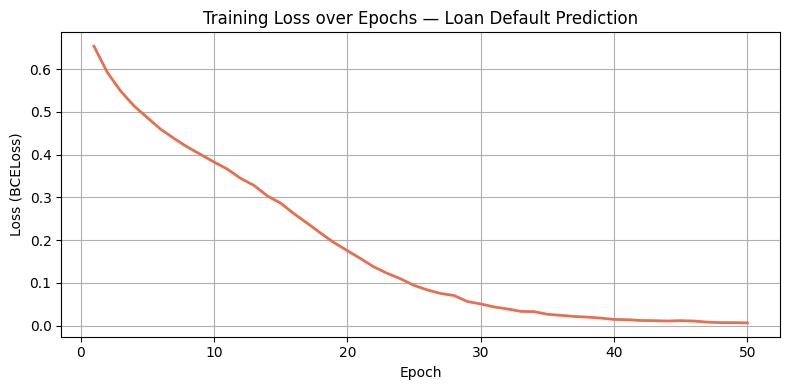

In [20]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), loss_values, color='#E76F51', linewidth=2)

plt.title('Training Loss over Epochs — Loan Default Prediction')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCELoss)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 4. Displaying Predicted vs. Actual Outcomes

After training and evaluating the model, it is helpful to see the model's
predictions for individual test examples and compare them to the actual
true labels. This gives a clearer sense of where the model is performing
well and where it may be struggling.

The following cell iterates through the test dataset using `test_loader`.
For each batch of test data, it:
1. Passes the features through the trained model to get predicted probabilities.
2. Converts probabilities to binary predictions (0 or 1) using a 0.5 threshold.
3. Collects the actual and predicted labels for all test examples.
4. Organises them into a pandas DataFrame for clear display.

In [21]:
import pandas as pd

# Set the model to evaluation mode
model.eval()

# Disable gradient calculation
with torch.no_grad():
    all_predicted = []
    all_labels    = []

    # Iterate through the test data
    for features, labels in test_loader:
        # Get model outputs
        outputs = model(features)

        # Convert probabilities to predicted class (0 or 1)
        predicted = (outputs > 0.5).float()

        # Append to lists
        all_predicted.extend(predicted.squeeze().tolist())
        all_labels.extend(labels.squeeze().tolist())

# Create a pandas DataFrame to display results
results_df = pd.DataFrame({
    'Actual Label':    [int(x) for x in all_labels],
    'Predicted Label': [int(x) for x in all_predicted]
})

# Map numeric labels to readable class names for clarity
label_map = {1: 'Good (1)', 0: 'Bad (0)'}
results_df['Actual']    = results_df['Actual Label'].map(label_map)
results_df['Predicted'] = results_df['Predicted Label'].map(label_map)

print("\n--- Predicted vs. Actual Outcomes for Test Data ---")
display(results_df[['Actual', 'Predicted']].reset_index(drop=True))

# Final accuracy summary
final_accuracy = (results_df['Actual Label'] == results_df['Predicted Label']).mean() * 100
print(f"\n--- Final Test Accuracy: {final_accuracy:.2f}% ---")


--- Predicted vs. Actual Outcomes for Test Data ---


,Actual,Predicted
0,Bad (0),Good (1)
1,Good (1),Bad (0)
2,Good (1),Bad (0)
3,Good (1),Good (1)
4,Good (1),Good (1)
...,...,...
195,Good (1),Good (1)
196,Bad (0),Bad (0)
197,Good (1),Good (1)
198,Good (1),Good (1)



--- Final Test Accuracy: 76.50% ---
